
#Assignment-#02
###Stereo Depth Estimation Using SIFT at corner and edges. At uniform region apply patch matching.  Complete each question by implementing the required functions and code cells, following the instructions provided.



### Import Libraries


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

### Define Camera Parameters

In [5]:
#Given the focal length and baseline
focal_length = 4152.073
baseline =  176.252

### Load Stereo Images

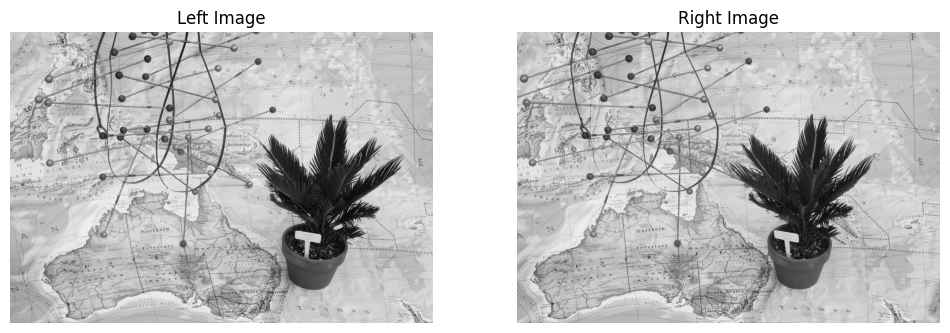

In [6]:
# Load left and right images

left_image = cv2.imread('/im0.png', cv2.IMREAD_GRAYSCALE)
right_image = cv2.imread('/im1.png', cv2.IMREAD_GRAYSCALE)

# Display images
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(left_image, cmap='gray')
plt.title('Left Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(right_image, cmap='gray')
plt.title('Right Image')
plt.axis('off')
plt.show()


For im0 (Left Image) and im1 (Right Image) I can see that there is a shift in overall image. The potted plant is more to the left in im0 and its more to the right in im1. Also the white T side inside the potted plant is tilted towards the left in im1. The world map in the background is also a bit shifted towards the right in im0 (left image) and we can see the left side of the world map a bit more compared in the right image.


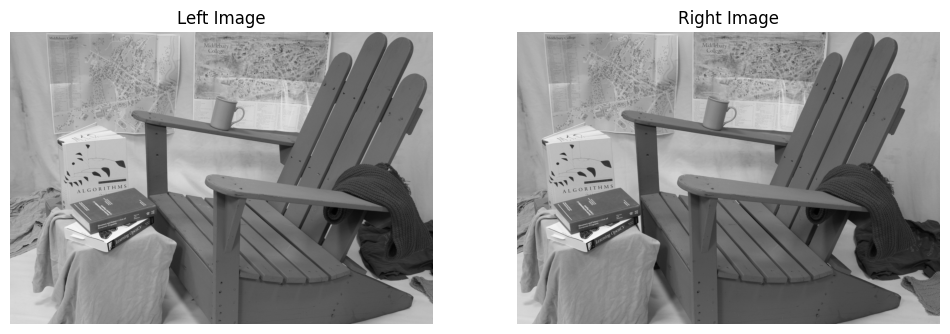

In [7]:
# Load left and right images

left_image = cv2.imread('/chair1.png', cv2.IMREAD_GRAYSCALE)
right_image = cv2.imread('/cahir0.png', cv2.IMREAD_GRAYSCALE)

# Display images
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(left_image, cmap='gray')
plt.title('Left Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(right_image, cmap='gray')
plt.title('Right Image')
plt.axis('off')
plt.show()


For cahir0.png (right image) and chair1.png(left image), we can notice some very sublte changes. For example the blanket behind the white book is a bit shifted towards the right in left image and towards the left in the right image. Also the blanket in the bottom right of the screen is a bit shifted towards the right in the left image compared to the picture in the right (chair1.png).

### Using SIFT find depth at edges and corner, Apply patchmatching find depth at uniform region

In [8]:
def depth_map_at_corner_and_edges(left_image, right_image, focal_length, baseline, ratio_test_threshold=0.7):

    sift = cv2.SIFT_create()
    kp1, des1 = sift.detectAndCompute(left_image, None)
    kp2, des2 = sift.detectAndCompute(right_image, None)

    bf = cv2.BFMatcher(cv2.NORM_L2)
    matches = bf.knnMatch(des1, des2, k=2)

    good_matches = []
    for m, n in matches:
        if m.distance < ratio_test_threshold * n.distance:
            good_matches.append(m)

    left_pts = []
    right_pts = []
    for match in good_matches:
        left_pts.append(kp1[match.queryIdx].pt)
        right_pts.append(kp2[match.trainIdx].pt)

    depth_map = np.zeros(left_image.shape, dtype=np.float32)

    for i in range(len(left_pts)):
        x_left, y_left = left_pts[i]
        x_right, y_right = right_pts[i]
        disparity = abs(x_left - x_right)
        if disparity > 0:
            depth = (focal_length * baseline) / disparity
            depth_map[int(y_left), int(x_left)] = depth

    return depth_map

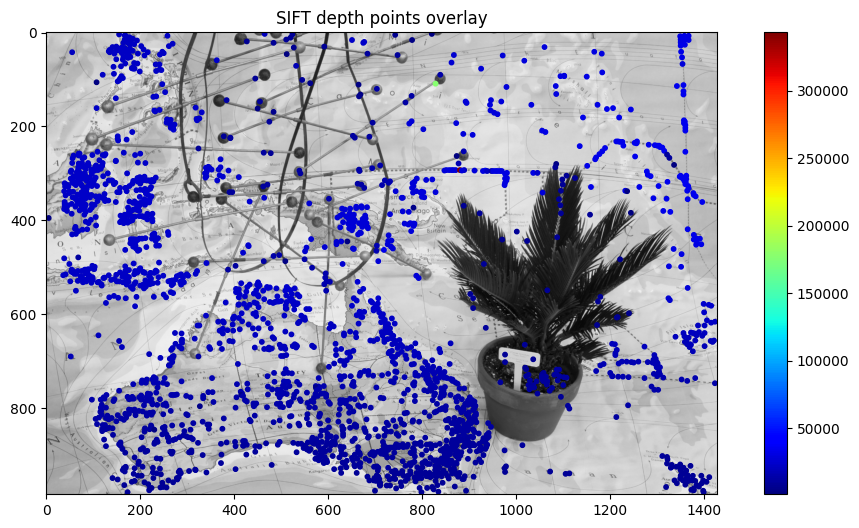

In [9]:
left_image = cv2.imread('/im0.png', cv2.IMREAD_GRAYSCALE) # '/chair1.png' for left
right_image = cv2.imread('/im1.png', cv2.IMREAD_GRAYSCALE) # '/cahir0.png; for right

depth_map = depth_map_at_corner_and_edges(left_image,right_image, focal_length, baseline)

# Display the matched image
plt.figure(figsize=(12,6))
plt.imshow(left_image, cmap='gray')
nonzero_y, nonzero_x = np.nonzero(depth_map)
plt.scatter(nonzero_x, nonzero_y, c=depth_map[nonzero_y, nonzero_x], cmap='jet', s=10)
plt.title("SIFT depth points overlay")
plt.colorbar()
plt.show()

In [17]:
def depth_map_at_uniform_region(left_image, right_image, focal_length, baseline, block_size=9, max_disp=64):

    depth_map = np.zeros(left_image.shape, dtype=np.float32)

    offset = block_size // 2

    for y in range(offset, left_image.shape[0] - offset, 2):
        for x in range(offset, left_image.shape[1] - offset, 2):

            left_block = left_image[y - offset:y + offset + 1, x - offset:x + offset + 1]

            best_sad = float('inf')
            best_disp = 0

            for disp in range(0, max_disp):
                right_x = x - disp
                if right_x - offset < 0:
                    continue
                right_block = right_image[y - offset:y + offset + 1, right_x - offset:right_x + offset + 1]

                sad = np.sum(np.abs(left_block.astype(np.float32) - right_block.astype(np.float32)))

                if sad < best_sad and sad < 8000:
                    best_sad = sad
                    best_disp = disp

            if best_disp > 0:
                depth = (focal_length * baseline) / best_disp
                depth_map[y, x] = depth

    return depth_map


Percentage valid depth estimates: 24.30140997214168


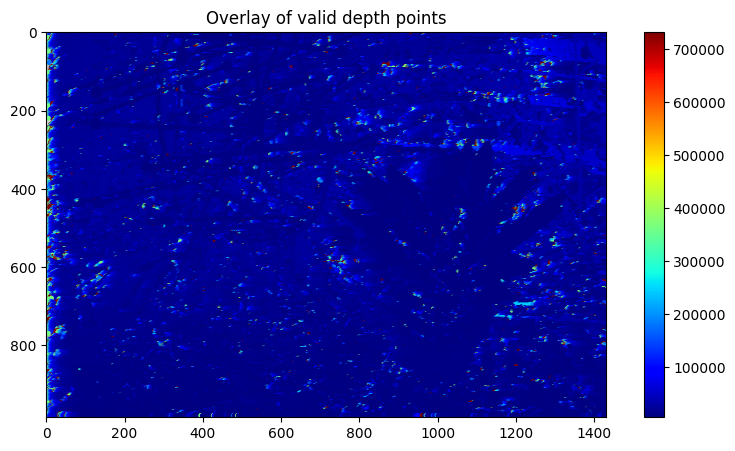

In [18]:
left_image = cv2.imread('/im0.png', cv2.IMREAD_GRAYSCALE)
right_image = cv2.imread('/im1.png', cv2.IMREAD_GRAYSCALE)

depth_map = depth_map_at_uniform_region(left_image, right_image, focal_length, baseline, block_size=7, max_disp=128)

num_valid = np.count_nonzero(depth_map)
pct_valid = 100 * num_valid / depth_map.size
print("Percentage valid depth estimates:", pct_valid)

plt.figure(figsize=(10,5))
plt.imshow(left_image, cmap='gray')
ys, xs = np.nonzero(depth_map)
plt.scatter(xs, ys, c=depth_map[ys, xs], cmap='jet', s=7)
plt.title("Overlay of valid depth points")
plt.colorbar()
plt.show()


### What does the disparity map represent? How does it relate to depth perception? Write the Mathematical Relationship (2 Points)

The disparity map is a map that is used to represent horizontal shift or distance between points in left and right images of a stereo pair.  Every value in the disparity map tells us how much the feature has moved / shifted. Closer objects have laster disparity whereas farther objects have smaller disparity.

It relates to depth perception because computer vision algorithms use this difference to estimate how far objects are from the observor or camera. The more the object moves horizontally between the two images, the nearer it is to the camera.

Here is the mathematical relationship between the two:

#                        **Z**=df⋅B

where Z = depth of object from the camera
f = focal length of the camera
B = distance between the cameras
d = horizontal shift (disparity)